In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
os.environ["GRB_LICENSE_FILE"] = r"C:\Users\PC3\Desktop\gurobi.lic"

import gurobipy as gp
from gurobipy import GRB 


# Data Builder

In [2]:
from dataclasses import replace
import importlib
import uc_experiment_builders
importlib.reload(uc_experiment_builders)

from uc_experiment_builders import (
    load_network_uc_from_excel_fixed,   # or build_data_ieee_case14 if using IEEE
    diversify_demand_archetypes_preserve_C,
    scale_renewables,
    make_scenario_data,
)

# ============================================================
# 0) Build base_data ONCE (run this cell after defining paths)
# ============================================================
# Example: Gabriel Excel dataset
XLSX_PATH = r"C:\Users\PC3\Desktop\Counterfactual-Explanations-for-optimization-problems\Mixed\UC-Experiments\RedEjemploRiesgoConfiabilidad.xlsx"  # <-- put your path

base_data = load_network_uc_from_excel_fixed(
    xlsx_path=XLSX_PATH,
    wind_scenario=2,
    solar_scenario="Alto",
    curt_penalty=1000.0,
    allow_shifting=False,
    carbon_price=0.0,
    slack_bus=0,
    rep_params=None,                      # <-- you already have these in notebook
    emission_rates=None,     # <-- you already have these
)

# ============================================================
# 1) Scenario knobs
# ============================================================
ARCHETYPE_SEED = 7
REN_SCALE = 2.0

# ============================================================
# 2) Build scenario data from base_data
# ============================================================
data, types = make_scenario_data(base_data, archetype_seed=ARCHETYPE_SEED, ren_scale=REN_SCALE)

print("Scenario ready:")
print("  ARCHETYPE_SEED =", ARCHETYPE_SEED)
print("  REN_SCALE      =", REN_SCALE)
print("  demand shape   =", data.demand.shape)
print("  #gens, #rens   =", len(data.gens), len(data.rens))


Scenario ready:
  ARCHETYPE_SEED = 7
  REN_SCALE      = 2.0
  demand shape   = (14, 24)
  #gens, #rens   = 6 4


In [3]:
from dataclasses import replace
import importlib
import uc_experiment_builders
importlib.reload(uc_experiment_builders)

from uc_experiment_builders import (
    load_network_uc_from_excel_fixed,
    make_scenario_data,
)

#XLSX_PATH = r"C:\Users\tomas\Documents\GitHub\Counterfactual-Explanations-for-optimization-problems\Mixed\UC-Experiments\RedEjemploRiesgoConfiabilidad.xlsx"
XLSX_PATH = r"C:\Users\PC3\Desktop\Counterfactual-Explanations-for-optimization-problems\Mixed\UC-Experiments\RedEjemploRiesgoConfiabilidad.xlsx"

ARCHETYPE_SEED = 5
REN_SCALE = 2.0

def build_data(
    *,
    wind_scenario=2,
    solar_scenario="Alto",
    curt_penalty=1000.0,
    allow_shifting=False,
    carbon_price=0.0,
    slack_bus=0,
    rep_params=None,
    emission_rates=None,
    archetype_seed=ARCHETYPE_SEED,
    ren_scale=REN_SCALE,
):
    base_data = load_network_uc_from_excel_fixed(
        xlsx_path=XLSX_PATH,
        wind_scenario=wind_scenario,
        solar_scenario=solar_scenario,
        curt_penalty=curt_penalty,
        allow_shifting=allow_shifting,
        carbon_price=carbon_price,
        slack_bus=slack_bus,
        rep_params=rep_params,
        emission_rates=emission_rates,
    )

    data, types = make_scenario_data(base_data, archetype_seed=archetype_seed, ren_scale=ren_scale)
    return data, types


In [4]:
def compose_foils(*foils):
    """Return a foil that applies all non-None foils in sequence."""
    foils = [f for f in foils if f is not None]
    if not foils:
        return None

    def _all(m, var, *args, **kwargs):
        for f in foils:
            f(m, var, *args, **kwargs)
    return _all


def _get_var(var, name_candidates):
    """
    Helper to fetch a variable array from `var` using multiple possible keys.
    Example: _get_var(var, ["u", "U", "commit", "on"])
    """
    for nm in name_candidates:
        if isinstance(var, dict) and nm in var:
            return var[nm]
        if hasattr(var, nm):
            return getattr(var, nm)
    raise KeyError(f"Could not find any of {name_candidates} in var.")


def _as_list(x):
    if x is None:
        return []
    return list(x) if isinstance(x, (list, tuple, set)) else [x]

### Foils

In [5]:
def foil_force_on(g, times):
    """
    Enforce u[g,t] = 1 for t in times.
    """
    times = _as_list(times)

    def _f(m, var, *args, **kwargs):
        u = _get_var(var, ["u", "U", "on", "commit"])
        for t in times:
            m.addConstr(u[g, t] == 1, name=f"foil_force_on_g{g}_t{t}")
    return _f

def foil_force_off(g, times):
    """
    Enforce u[g,t] = 0 for t in times.
    """
    times = _as_list(times)

    def _f(m, var, *args, **kwargs):
        u = _get_var(var, ["u", "U", "on", "commit"])
        for t in times:
            m.addConstr(u[g, t] == 0, name=f"foil_force_off_g{g}_t{t}")
    return _f


def foil_force_startup(g, t):
    """
    Enforce v[g,t] = 1 (startup event). Requires startup var v.
    """
    def _f(m, var, *args, **kwargs):
        v = _get_var(var, ["v", "V", "startup"])
        m.addConstr(v[g, t] == 1, name=f"foil_force_startup_g{g}_t{t}")
    return _f

def foil_force_shutdown(g, t):
    """
    Enforce w[g,t] = 1 (shutdown event). Requires shutdown var w.
    """
    def _f(m, var, *args, **kwargs):
        w = _get_var(var, ["w", "W", "shutdown"])
        m.addConstr(w[g, t] == 1, name=f"foil_force_shutdown_g{g}_t{t}")
    return _f



In [6]:
def foil_flip_one_commitment(sol_factual, g, t):
    """
    If factual u[g,t]=1 -> enforce u[g,t]=0.
    If factual u[g,t]=0 -> enforce u[g,t]=1.
    """
    uF = sol_factual["u"]
    target = 1 - int(round(uF[g, t]))

    def _f(m, var, *args, **kwargs):
        u = _get_var(var, ["u", "U", "on", "commit"])
        m.addConstr(u[g, t] == target, name=f"foil_flip_u_g{g}_t{t}")
    return _f

def foil_flip_unit_window(sol_factual, g, t0, t1):
    """
    Enforce u[g,t] = 1-uF[g,t] for all t in [t0,t1].
    """
    uF = sol_factual["u"]

    def _f(m, var, *args, **kwargs):
        u = _get_var(var, ["u", "U", "on", "commit"])
        for t in range(t0, t1 + 1):
            target = 1 - int(round(uF[g, t]))
            m.addConstr(u[g, t] == target, name=f"foil_flipwin_u_g{g}_t{t}")
    return _f

def foil_change_on_hours(sol_factual, g, delta_on_hours):
    """
    Enforce sum_t u[g,t] = sum_t uF[g,t] + delta_on_hours.
    Positive delta => more committed hours, negative => fewer.
    """
    uF = sol_factual["u"]
    target = int(round(np.sum(uF[g, :])) + int(delta_on_hours))

    def _f(m, var, *args, **kwargs):
        u = _get_var(var, ["u", "U", "on", "commit"])
        T = u.shape[1]
        m.addConstr(gp.quicksum(u[g, t] for t in range(T)) == target,
                    name=f"foil_onhours_g{g}_d{delta_on_hours}")
    return _f


In [7]:
def foil_at_least_k_on(units, t, k):
    """
    Enforce sum_{g in units} u[g,t] >= k.
    """
    units = _as_list(units)

    def _f(m, var, *args, **kwargs):
        u = _get_var(var, ["u", "U", "on", "commit"])
        m.addConstr(gp.quicksum(u[g, t] for g in units) >= int(k),
                    name=f"foil_kon_t{t}_k{k}")
    return _f

def foil_at_most_k_on(units, t, k):
    """
    Enforce sum_{g in units} u[g,t] <= k.
    """
    units = _as_list(units)

    def _f(m, var, *args, **kwargs):
        u = _get_var(var, ["u", "U", "on", "commit"])
        m.addConstr(gp.quicksum(u[g, t] for g in units) <= int(k),
                    name=f"foil_koff_t{t}_k{k}")
    return _f

def foil_min_startups(t0, t1, min_startups, gens=None):
    """
    Enforce sum_{g in gens, t in [t0,t1]} v[g,t] >= min_startups.
    """
    def _f(m, var, *args, **kwargs):
        v = _get_var(var, ["v", "V", "startup"])
        nG, T = v.shape
        G = range(nG) if gens is None else _as_list(gens)
        m.addConstr(
            gp.quicksum(v[g, t] for g in G for t in range(t0, t1 + 1)) >= int(min_startups),
            name=f"foil_min_startups_{t0}_{t1}_{min_startups}"
        )
    return _f

def foil_max_startups(t0, t1, max_startups, gens=None):
    """
    Enforce sum_{g in gens, t in [t0,t1]} v[g,t] <= max_startups.
    """
    def _f(m, var, *args, **kwargs):
        v = _get_var(var, ["v", "V", "startup"])
        nG, T = v.shape
        G = range(nG) if gens is None else _as_list(gens)
        m.addConstr(
            gp.quicksum(v[g, t] for g in G for t in range(t0, t1 + 1)) <= int(max_startups),
            name=f"foil_max_startups_{t0}_{t1}_{max_startups}"
        )
    return _f


### Example

In [8]:
from uc_pipeline import solve_uc_with_cost,build_cost_vector_network_uc,default_initial_conditions ,build_index_map_network_uc


nG = len(data.gens)
nR = len(data.rens)
nB = int(data.nB)
nL = len(data.lines)
T  = int(data.T)

idx = build_index_map_network_uc(nG=nG, nR=nR, nB=nB, nL=nL, T=T, major="t")
u_init, p_init, on_time_init, off_time_init = default_initial_conditions(data)

window_size = 3
per_bus_neutrality = True


fuel_cost_vec     = np.array([g.fuel_cost     for g in data.gens], dtype=float)
no_load_cost_vec  = np.array([g.no_load_cost  for g in data.gens], dtype=float)
su_cost_vec       = np.array([g.SU_cost       for g in data.gens], dtype=float)
sd_cost_vec       = np.array([g.SD_cost       for g in data.gens], dtype=float)

emission_rate_vec = np.array(
    [getattr(g, "emission_rate", 0.0) for g in data.gens],
    dtype=float
)

# Renewables curtailment cost (nR × T)
if nR > 0:
    curt_cost_mat = np.vstack([r.curt_cost for r in data.rens])
else:
    curt_cost_mat = np.zeros((0, T))

c0 = build_cost_vector_network_uc(
    idx=idx,
    fuel_cost=fuel_cost_vec,
    emission_rate=emission_rate_vec,
    carbon_price=float(getattr(data, "carbon_price", 0.0)),
    no_load_cost=no_load_cost_vec,
    su_cost=su_cost_vec,
    sd_cost=sd_cost_vec,
    curt_cost=curt_cost_mat,
    pi_plus=data.pi_plus,      # demand shift up price
    pi_minus=data.pi_minus,    # demand shift down price
    voll=float(getattr(data, "voll", 20000.0)),
)


mF, solF, zF = solve_uc_with_cost(
    data, idx, c0,
    window_size, per_bus_neutrality,
    u_init, p_init, on_time_init, off_time_init,
    extra_constr_fn=None,
    output_flag=True
)


Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2653481
Academic license 2653481 - for non-commercial use only - registered to to___@ug.uchile.cl
Set parameter OutputFlag to value 1
Set parameter IgnoreNames to value 0
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11.0 (26100.2))

CPU model: Intel(R) Core(TM) i7-14700, instruction set [SSE2|AVX|AVX2]
Thread count: 20 physical cores, 28 logical processors, using up to 28 threads

Academic license 2653481 - for non-commercial use only - registered to to___@ug.uchile.cl
Optimize a model with 4080 rows, 2496 columns and 9634 nonzeros (Min)
Model fingerprint: 0x079ba2a5
Model has 768 linear objective coefficients
Variable types: 2064 continuous, 432 integer (432 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+02]
  Objective range  [4e+01, 5e+04]
  Bounds range     [1e+00, 1e+00]
  RHS range        [2e-01, 3e+02]

Presolve removed 3064 rows and 1242 columns
Presolve time: 

In [18]:
import numpy as np

from uc_pipeline import NetworkUCData
from b3_ncxplain import (
    run_ncxplain_uc,
    run_E3_ncxplain_shift_and_curt_prices_emissions,
    foil_force_unit_commitment,
)
from b3_ncxplain import run_ncxplain_uc

data, types = build_data(allow_shifting=False)

foil1 = foil_flip_one_commitment(sol_factual=solF, g=2, t=9)
foil2 = foil_flip_one_commitment(sol_factual=solF, g=1, t=9)
foil3 = foil_flip_one_commitment(sol_factual=solF, g=2, t=4)


foils = compose_foils(foil1,foil2,foil3)

out = run_ncxplain_uc(
    data=data,
    window_size=3,
    per_bus_neutrality=True,
    foil_fn=foils,   # <- your foil
    mutables={"gen_costs"},
    bounds={"fuel": (0, 500), "no_load": (0, 5000), "su": (0, 50000), "sd": (0, 50000)},
    weights={"gen_costs": 1.0},
    verbose=True
)


print(out["status"])



[NCX it=01] gap=-9.31323e-10 | stop_tol=2.3 | MP_obj=6266.0
OPTIMAL


In [19]:
import numpy as np

# ---- imports from your codebase ----
from uc_pipeline import (
    build_index_map_network_uc,
    default_initial_conditions,
    build_cost_vector_network_uc,
    solve_uc_with_cost,
)
from b3_ncxplain import run_ncxplain_uc
# you should already have these somewhere:
# - foil_flip_one_commitment
# - compose_foils

# -----------------------------
# 1) Build data
# -----------------------------
data, types = build_data(allow_shifting=False)

# -----------------------------
# 2) Dimensions + idx map + initial conditions
# -----------------------------
nG = len(data.gens)
nR = len(data.rens)
nB = data.nB
nL = len(data.lines)
T  = data.T

idx = build_index_map_network_uc(nG=nG, nR=nR, nB=nB, nL=nL, T=T, major="t")
u_init, p_init, on_time_init, off_time_init = default_initial_conditions(data)

print(f"[sanity] nG={nG}, nR={nR}, nB={nB}, nL={nL}, T={T}")
print(f"[sanity] idx.n_vars = {getattr(idx, 'n_vars', None)}")

# -----------------------------
# 3) Build base cost vector c0
# -----------------------------
fuel_cost_vec     = np.array([float(g.fuel_cost) for g in data.gens], dtype=float)
emission_rate_vec = np.array([float(getattr(g, "emission_rate", 0.0)) for g in data.gens], dtype=float)
no_load_cost_vec  = np.array([float(getattr(g, "no_load_cost", 0.0)) for g in data.gens], dtype=float)
su_cost_vec       = np.array([float(getattr(g, "SU_cost", 0.0)) for g in data.gens], dtype=float)
sd_cost_vec       = np.array([float(getattr(g, "SD_cost", 0.0)) for g in data.gens], dtype=float)

curt_cost_mat = np.vstack([r.curt_cost for r in data.rens]) if nR > 0 else np.zeros((0, T))

# NOTE: allow_shifting=False => pi_plus/pi_minus might be absent or zeros
pi_plus  = getattr(data, "pi_plus", None)
pi_minus = getattr(data, "pi_minus", None)

c0 = build_cost_vector_network_uc(
    idx=idx,
    fuel_cost=fuel_cost_vec,
    emission_rate=emission_rate_vec,
    carbon_price=float(getattr(data, "carbon_price", 0.0)),
    no_load_cost=no_load_cost_vec,
    su_cost=su_cost_vec,
    sd_cost=sd_cost_vec,
    curt_cost=curt_cost_mat,
    pi_plus=pi_plus,
    pi_minus=pi_minus,
    voll=float(getattr(data, "voll", 20000.0)),
)

print(f"[sanity] c0 shape = {c0.shape}, min={c0.min():.3g}, max={c0.max():.3g}")

# -----------------------------
# 4) Solve factual UC under c0 => solF
# -----------------------------
mF, solF, zF = solve_uc_with_cost(
    data, idx, c0,
    window_size=3,
    per_bus_neutrality=True,
    u_init=u_init, p_init=p_init, on_time_init=on_time_init, off_time_init=off_time_init,
    extra_constr_fn=None,
    output_flag=0,
)
assert solF is not None, f"Factual solve failed, status={int(mF.Status)}"
print("[sanity] factual solve OK")

# -----------------------------
# 5) Build foils from solF
# -----------------------------
foil1 = foil_flip_one_commitment(sol_factual=solF, g=2, t=9)
foil2 = foil_flip_one_commitment(sol_factual=solF, g=1, t=9)
foil3 = foil_flip_one_commitment(sol_factual=solF, g=2, t=4)
foils = compose_foils(foil1, foil2, foil3)

# -----------------------------
# 6) Sanity check: foil feasibility under c0
# -----------------------------
mFoil, solFoil, zFoil = solve_uc_with_cost(
    data, idx, c0,
    window_size=3,
    per_bus_neutrality=True,
    u_init=u_init, p_init=p_init, on_time_init=on_time_init, off_time_init=off_time_init,
    extra_constr_fn=foils,
    output_flag=0,
)
assert solFoil is not None, f"Foil infeasible under base costs, status={int(mFoil.Status)}"
print("[sanity] foil solve OK (feasible under c0)")

# -----------------------------
# 7) Run NCXplain with gen_costs mutable
# -----------------------------
out = run_ncxplain_uc(
    data=data,
    window_size=3,
    per_bus_neutrality=True,
    foil_fn=foils,   # <-- IMPORTANT: use foils
    mutables={"gen_costs"},
    bounds={"fuel": (0, 500), "no_load": (0, 5000), "su": (0, 50000), "sd": (0, 50000)},
    weights={"gen_costs": 1.0},
    verbose=True,
)

print("[sanity] out['status'] =", out.get("status"))


[sanity] nG=6, nR=4, nB=14, nL=20, T=24
[sanity] idx.n_vars = 2496
[sanity] c0 shape = (2496,), min=0, max=5.31e+04
[sanity] factual solve OK
[sanity] foil solve OK (feasible under c0)
[NCX it=01] gap=-9.31323e-10 | stop_tol=2.3 | MP_obj=6266.0
[sanity] out['status'] = OPTIMAL


In [15]:

# ----------------------------
# Helpers: derive time series
# ----------------------------
def _get_T(data):
    return int(getattr(data, "T", data.demand.shape[1]))

def _renewable_avail_matrix(data):
    # (nR,T)
    if len(data.rens) == 0:
        return np.zeros((0, _get_T(data)))
    return np.vstack([np.asarray(r.avail, dtype=float).reshape(1, -1) for r in data.rens])

def _renewable_used_matrix(data, sol):
    # used = avail - curt  (nR,T)
    avail = _renewable_avail_matrix(data)
    curt  = np.asarray(sol.get("curt", np.zeros_like(avail)), dtype=float)
    return avail - curt

def _total_demand(data):
    # total raw demand (T,)
    return np.asarray(data.demand, dtype=float).sum(axis=0)

def _net_load_total(data, sol):
    # net load = demand + splus - sminus (T,)
    demand = np.asarray(data.demand, dtype=float)
    splus  = np.asarray(sol.get("splus", np.zeros_like(demand)), dtype=float)
    sminus = np.asarray(sol.get("sminus", np.zeros_like(demand)), dtype=float)
    return (demand + splus - sminus).sum(axis=0)

def _shed_total(sol):
    shed = np.asarray(sol.get("shed", 0.0), dtype=float)
    if np.isscalar(shed):
        return np.array([float(shed)])
    return shed.sum(axis=0)  # (T,)

def _served_total(data, sol):
    # served = net_load - shed
    return _net_load_total(data, sol) - _shed_total(sol)

def _gen_matrix(sol):
    # (nG,T)
    return np.asarray(sol["p"], dtype=float)

def _gen_total(sol):
    return _gen_matrix(sol).sum(axis=0)  # (T,)

def _renew_used_total(data, sol):
    return _renewable_used_matrix(data, sol).sum(axis=0)  # (T,)

def _curtail_total(sol):
    curt = np.asarray(sol.get("curt", 0.0), dtype=float)
    if np.isscalar(curt):
        return np.array([float(curt)])
    return curt.sum(axis=0)

def _emissions_total(data, sol):
    # total emissions per hour: sum_g er[g]*p[g,t]
    er = np.array([float(g.emission_rate) for g in data.gens], dtype=float).reshape(-1, 1)
    p  = _gen_matrix(sol)
    return (er * p).sum(axis=0)  # (T,)

def _voll_cost_total(data, sol):
    # shedding cost per hour = VOLL * shed_total
    # NOTE: in NetworkUCData you used VOLL (uppercase) in one file and voll in another
    voll = float(getattr(data, "VOLL", getattr(data, "voll", 20000.0)))
    return voll * _shed_total(sol)

def _curtail_cost_total(data, sol):
    # if you want the curtailment penalty cost per hour: sum_r curt_cost[r,t] * curt[r,t]
    if len(data.rens) == 0:
        return np.zeros(_get_T(data))
    curt_cost = np.vstack([np.asarray(r.curt_cost, dtype=float).reshape(1, -1) for r in data.rens])
    curt = np.asarray(sol["curt"], dtype=float)
    return (curt_cost * curt).sum(axis=0)

# ----------------------------
# Plotting functions
# ----------------------------
def plot_demand_served_shed(data, sol, title="Demand vs Served vs Shed"):
    T = _get_T(data)
    t = np.arange(T)

    demand_raw = _total_demand(data)
    net_load   = _net_load_total(data, sol)
    served     = _served_total(data, sol)
    shed       = _shed_total(sol)

    plt.figure()
    plt.plot(t, demand_raw, label="Raw demand (sum buses)")
    plt.plot(t, net_load,   label="Net load (demand+splus-sminus)")
    plt.plot(t, served,     label="Served load")
    plt.plot(t, shed,       label="Load shedding")
    plt.title(title)
    plt.xlabel("Hour")
    plt.ylabel("MW")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

def plot_generation_mix(data, sol, title="Generation mix (thermal + renew used)"):
    T = _get_T(data)
    t = np.arange(T)

    g_total = _gen_total(sol)
    r_used  = _renew_used_total(data, sol)
    served  = _served_total(data, sol)

    plt.figure()
    plt.plot(t, served, label="Served load")
    plt.plot(t, g_total, label="Thermal generation (sum p_g)")
    plt.plot(t, r_used, label="Renewables used (sum avail-curt)")
    plt.title(title)
    plt.xlabel("Hour")
    plt.ylabel("MW")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

def plot_curtailment(data, sol, title="Curtailment"):
    T = _get_T(data)
    t = np.arange(T)

    curt_total = _curtail_total(sol)
    avail_total = _renewable_avail_matrix(data).sum(axis=0) if len(data.rens) else np.zeros(T)
    used_total  = _renew_used_total(data, sol)

    plt.figure()
    plt.plot(t, avail_total, label="Renewables available")
    plt.plot(t, used_total,  label="Renewables used")
    plt.plot(t, curt_total,  label="Curtailment")
    plt.title(title)
    plt.xlabel("Hour")
    plt.ylabel("MW")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

def plot_emissions(data, sol, title="Emissions"):
    T = _get_T(data)
    t = np.arange(T)

    E = _emissions_total(data, sol)

    plt.figure()
    plt.plot(t, E, label="Hourly emissions (sum er_g * p_g)")
    plt.title(title)
    plt.xlabel("Hour")
    plt.ylabel("Emission units (er*MW)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

def plot_shedding_and_costs(data, sol, title="Shedding + VOLL cost + Curtailment cost"):
    T = _get_T(data)
    t = np.arange(T)

    shed_mw = _shed_total(sol)
    voll_cost = _voll_cost_total(data, sol)
    curt_cost = _curtail_cost_total(data, sol)

    plt.figure()
    plt.plot(t, shed_mw, label="Shed (MW)")
    plt.title(title + " (MW)")
    plt.xlabel("Hour")
    plt.ylabel("MW")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    plt.figure()
    plt.plot(t, voll_cost, label="VOLL cost per hour")
    plt.plot(t, curt_cost, label="Curtailment penalty per hour")
    plt.title(title + " (cost)")
    plt.xlabel("Hour")
    plt.ylabel("$")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

def plot_all_dashboard(data, sol, tag="Solution"):
    plot_demand_served_shed(data, sol, title=f"{tag}: Demand/Served/Shedding")
    plot_generation_mix(data, sol, title=f"{tag}: Generation mix")
    plot_curtailment(data, sol, title=f"{tag}: Curtailment")
    plot_emissions(data, sol, title=f"{tag}: Emissions")
    plot_shedding_and_costs(data, sol, title=f"{tag}: Reliability & cost")
    plt.show()

# ----------------------------
# Usage with your `out`
# ----------------------------
# out is result from run_B3_ncxplain_shift_prices or run_E3_...
# Example:
# plot_all_dashboard(data, out["sol_factual"], tag="Factual")
# plot_all_dashboard(data, out["sol_foil"],    tag="Foil")
# plot_all_dashboard(data, out["sol_opt"],     tag="Opt under new coeffs")


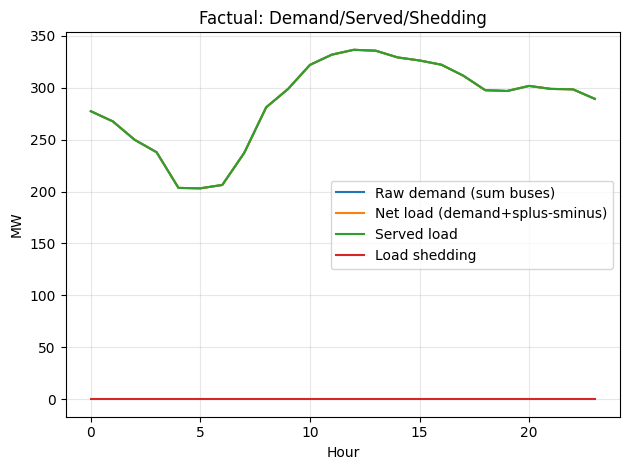

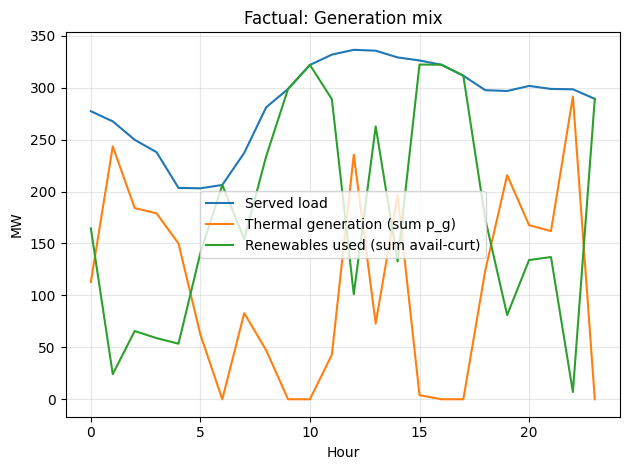

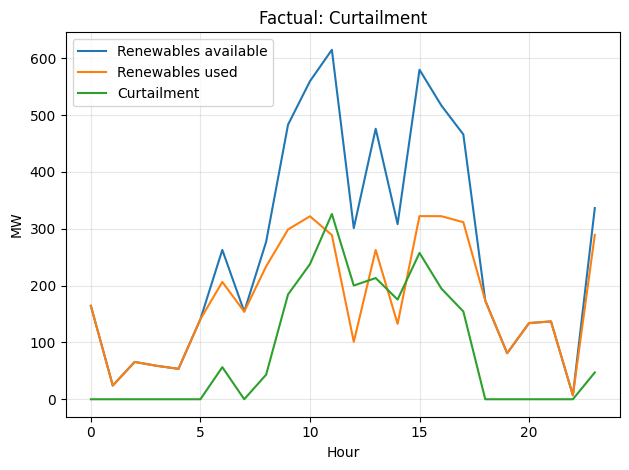

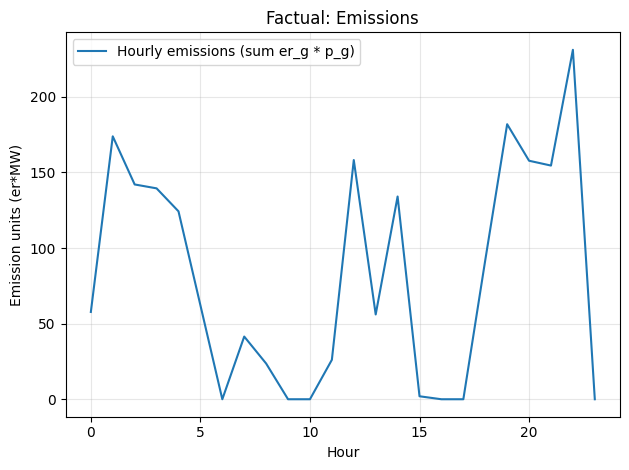

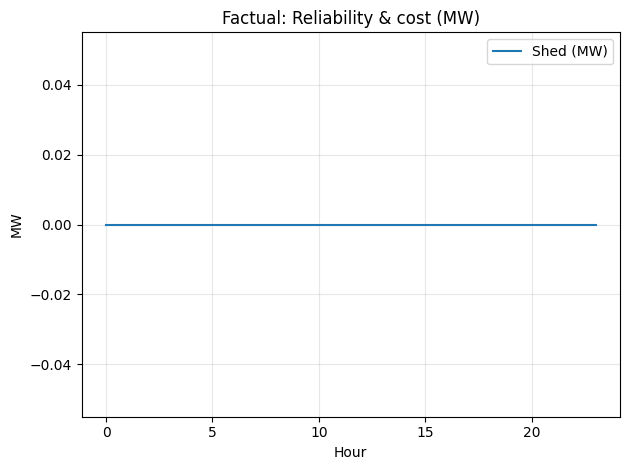

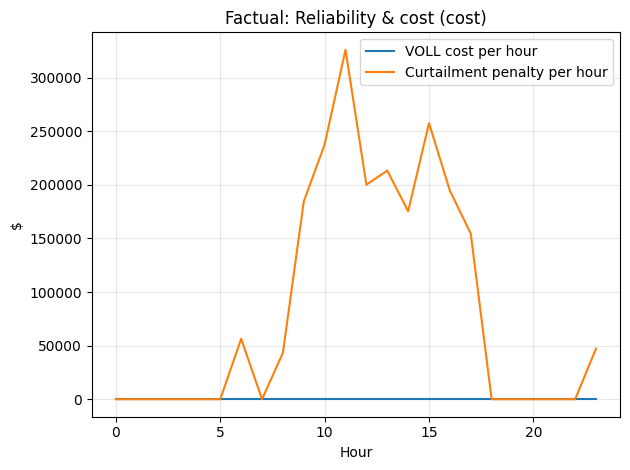

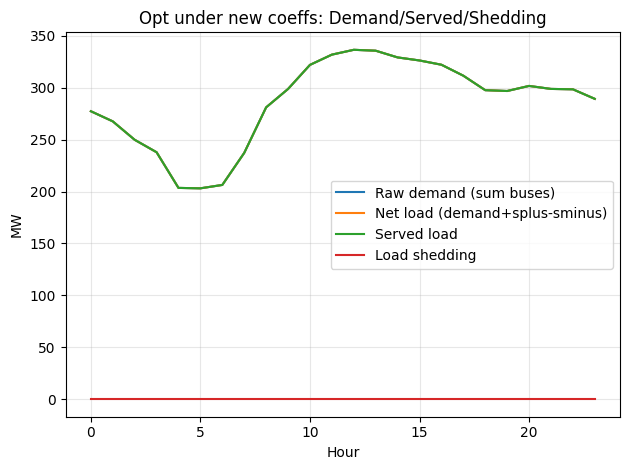

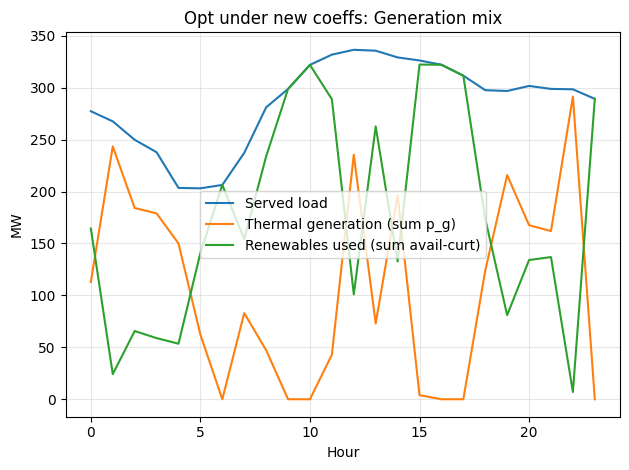

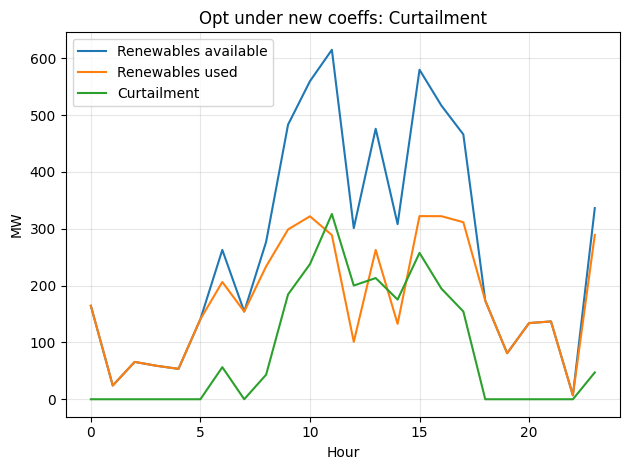

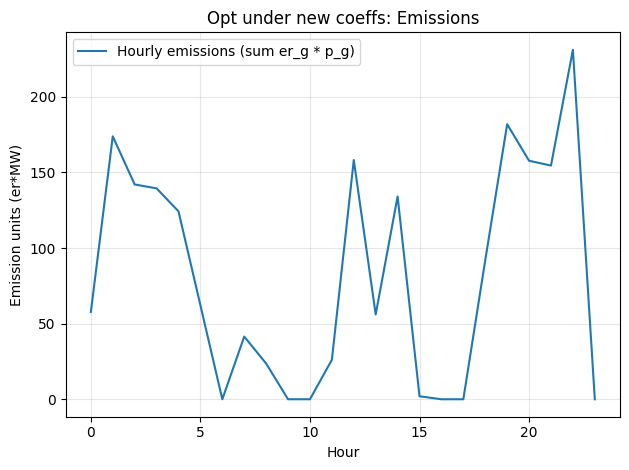

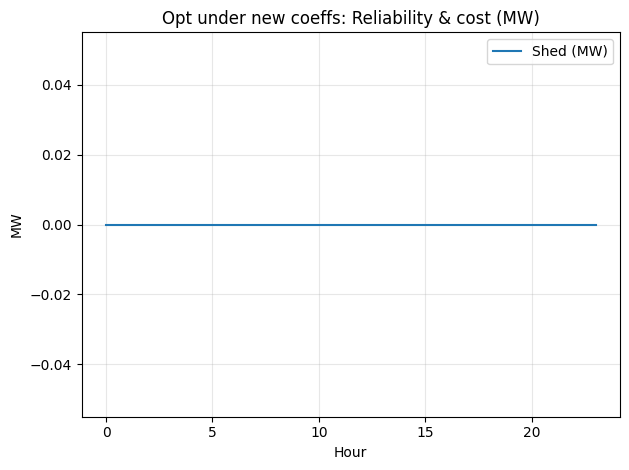

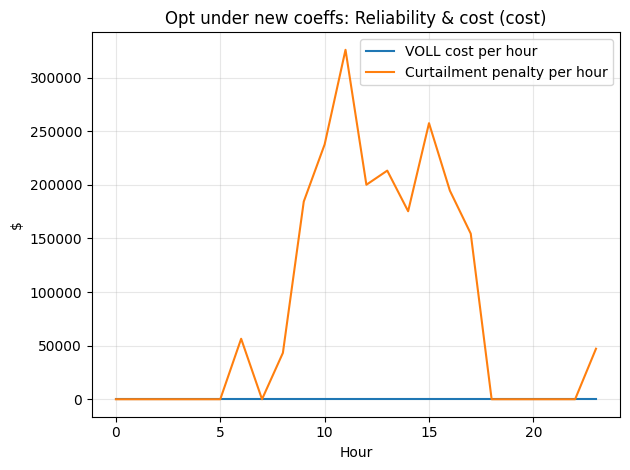

In [11]:
plot_all_dashboard(data, out["sol_factual"], tag="Factual")
plot_all_dashboard(data, out["sol_opt"],     tag="Opt under new coeffs")